##### F7 — K-means Cluster Analysis (Hyperparameter Tuning, 6D)

##### Purpose

F7 has shown the biggest emergent multi-dimensional improvement.

This notebook characterizes F7's cluster structure with a special 
focus on the **geographic isolation of the best value** from the older 
high-y points. K-means may treat the new best as a single-cluster 
outlier which is a meaningful structural finding about multi-modal exploration.

##### Function: F7 — Hyperparameter Tuning, 6D
- Domain: [0,1]⁶
- Y range: positive, bounded (0.003 to 2.15)
- Preprocessing for clustering: raw y (no transformation needed)
- Known structure: at least two high-y regions; GP says x3 is irrelevant; all other dims active
- Special diagnostic: distance from R11 win to next-best point

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cdist

# Load F7 data
data = np.load('F7_data.npz')
X = data['X']
y = data['y']

print(f"F7 dataset: {len(X)} points")
print(f"  y range: [{y.min():.4f}, {y.max():.4f}]")
print(f"  Best:    X={X[y.argmax()]}, y={y.max():.4f}")
print(f"  Top 5 y values:")
for idx in np.argsort(y)[-5:][::-1]:
    print(f"    X={X[idx]}, y={y[idx]:+.4f}")

F7 dataset: 42 points
  y range: [0.0027, 2.6543]
  Best:    X=[0.268251 0.374404 0.393939 0.321976 0.303158 0.674861], y=2.6543
  Top 5 y values:
    X=[0.268251 0.374404 0.393939 0.321976 0.303158 0.674861], y=+2.6543
    X=[0.21     0.460953 0.293939 0.301005 0.308215 0.71551 ], y=+2.1492
    X=[0.11  0.492 0.247 0.25  0.32  0.731], y=+1.8129
    X=[0.1   0.492 0.247 0.25  0.32  0.731], y=+1.7989
    X=[0.1   0.492 0.247 0.25  0.37  0.731], y=+1.6894


##### Step 1 — Silhouette analysis

In [3]:
sil_scores = {}
for k in range(2, min(7, len(X))):
    km = KMeans(n_clusters=k, n_init=20, random_state=42).fit(X)
    sil_scores[k] = silhouette_score(X, km.labels_)
    print(f"  k={k}: silhouette = {sil_scores[k]:+.4f}")

best_k = max(sil_scores, key=sil_scores.get)
print(f"\n→ Natural cluster count: k = {best_k}")

  k=2: silhouette = +0.2528
  k=3: silhouette = +0.2786
  k=4: silhouette = +0.3093
  k=5: silhouette = +0.3185
  k=6: silhouette = +0.3273

→ Natural cluster count: k = 6


##### Step 2 — Cluster characterization

Look for whether the new best point ends up isolated in its own cluster 
or grouped with the older high-y cluster.

In [4]:
km = KMeans(n_clusters=best_k, n_init=20, random_state=42).fit(X)
labels = km.labels_

print(f"Cluster characterization (k={best_k}):")
print(f"{'cluster':>8} {'n':>4} {'mean_y':>8} {'max_y':>8} {'std_y':>8} {'centroid':>40}")
print("  " + "-" * 80)

best_cluster = int(labels[y.argmax()])
for i in range(best_k):
    members = (labels == i)
    n = int(members.sum())
    mean_y = float(np.mean(y[members]))
    max_y = float(np.max(y[members]))
    std_y = float(np.std(y[members])) if n > 1 else 0.0
    centroid = km.cluster_centers_[i]
    marker = " ★" if i == best_cluster else ""
    centroid_str = "[" + ", ".join(f"{v:.2f}" for v in centroid) + "]"
    print(f"{i:>8} {n:>4} {mean_y:>+8.4f} {max_y:>+8.4f} {std_y:>8.4f} "
          f"{centroid_str}{marker}")

print(f"\n→ Current best belongs to cluster {best_cluster} (n={(labels==best_cluster).sum()})")

Cluster characterization (k=6):
 cluster    n   mean_y    max_y    std_y                                 centroid
  --------------------------------------------------------------------------------
       0   13  +1.3460  +2.6543   0.6905 [0.10, 0.50, 0.23, 0.23, 0.33, 0.75] ★
       1    8  +0.2070  +0.6751   0.2001 [0.69, 0.19, 0.46, 0.25, 0.24, 0.33]
       2    3  +0.0337  +0.0954   0.0436 [0.73, 0.29, 0.03, 0.86, 0.61, 0.09]
       3    7  +0.0345  +0.1005   0.0342 [0.48, 0.50, 0.10, 0.31, 0.80, 0.65]
       4    5  +0.1897  +0.5628   0.2086 [0.63, 0.65, 0.50, 0.80, 0.51, 0.39]
       5    6  +0.4481  +0.8880   0.3145 [0.14, 0.27, 0.86, 0.68, 0.32, 0.74]

→ Current best belongs to cluster 0 (n=13)


##### Step 3 — Isolation analysis

How geographically isolated is the current best from the next-best points?
We compute distances from this point to all other points and 
identify its k nearest neighbors.

In [9]:
R11_idx = y.argmax()
R11_X = X[R11_idx]
R11_y = y[R11_idx]

# Distance from R11 to all other points
dists_from_R11 = np.linalg.norm(X - R11_X, axis=1)
dists_from_R11[R11_idx] = np.inf  # exclude self

# Top 5 nearest neighbors
nn_indices = np.argsort(dists_from_R11)[:5]
print(f"Best point at X={R11_X}, y={R11_y:+.4f}")
print(f"\n5 nearest neighbors:")
for rank, nn_idx in enumerate(nn_indices, 1):
    print(f"  #{rank}: dist={dists_from_R11[nn_idx]:.4f}, "
          f"y={y[nn_idx]:+.4f}, cluster={labels[nn_idx]}")

print(f"\nBest point cluster membership: {labels[R11_idx]}")
print(f"Other members of this cluster:")
cluster_members = np.where(labels == labels[R11_idx])[0]
for idx in cluster_members:
    if idx != R11_idx:
        print(f"  X={X[idx]}, y={y[idx]:+.4f}, "
              f"dist from R11={dists_from_R11[idx]:.4f}")

Best point at X=[0.268251 0.374404 0.393939 0.321976 0.303158 0.674861], y=+2.6543

5 nearest neighbors:
  #1: dist=0.1517, y=+2.1492, cluster=0
  #2: dist=0.2628, y=+1.8129, cluster=0
  #3: dist=0.2690, y=+1.7989, cluster=0
  #4: dist=0.2766, y=+1.6894, cluster=0
  #5: dist=0.2928, y=+1.4641, cluster=0

Best point cluster membership: 0
Other members of this cluster:
  X=[0.05789554 0.49167222 0.24742222 0.21811844 0.42042833 0.73096984], y=+1.3650, dist from R11=0.3273
  X=[0.17597754 0.6244165  0.29554198 0.46955276 0.09776977 0.72814108], y=+0.4754, dist from R11=0.3841
  X=[0.       0.719578 0.       0.       0.393604 0.774235], y=+0.2255, dist from R11=0.6841
  X=[0.021549 0.629991 0.044829 0.245593 0.2      0.786022], y=+0.7113, dist from R11=0.5262
  X=[0.058 0.492 0.247 0.25  0.42  0.731], y=+1.4074, dist from R11=0.3188
  X=[0.       0.236384 0.21312  0.       0.244205 1.      ], y=+0.4157, dist from R11=0.5801
  X=[0.0472 0.5015 0.2517 0.2456 0.4286 0.7222], y=+1.3291, dist f

##### Step 4 — High-y sub-region (top 10% by y)

In [6]:
y_threshold = np.percentile(y, 90)
high_y_mask = y > y_threshold

print(f"\nHigh-y sub-region (y > {y_threshold:.4f}, top 10%):")
print(f"  Count: {high_y_mask.sum()}")
if high_y_mask.sum() > 0:
    X_high = X[high_y_mask]
    y_high = y[high_y_mask]
    
    # Which clusters do high-y points belong to?
    high_y_clusters = labels[high_y_mask]
    print(f"  Cluster membership of high-y points: {high_y_clusters}")
    print(f"  Number of distinct clusters in top 10%: {len(set(high_y_clusters))}")
    
    print(f"\n  High-y X ranges:")
    for dim_i in range(6):
        dim_lbl = f"x{dim_i+1}"
        print(f"    {dim_lbl}: [{X_high[:, dim_i].min():.3f}, {X_high[:, dim_i].max():.3f}], "
              f"spread = {np.ptp(X_high[:, dim_i]):.3f}")


High-y sub-region (y > 1.6669, top 10%):
  Count: 5
  Cluster membership of high-y points: [0 0 0 0 0]
  Number of distinct clusters in top 10%: 1

  High-y X ranges:
    x1: [0.100, 0.268], spread = 0.168
    x2: [0.374, 0.492], spread = 0.118
    x3: [0.247, 0.394], spread = 0.147
    x4: [0.250, 0.322], spread = 0.072
    x5: [0.303, 0.370], spread = 0.067
    x6: [0.675, 0.731], spread = 0.056


##### Step 5 — PCA visualization

PCA explained variance: PC1 = 0.318, PC2 = 0.235


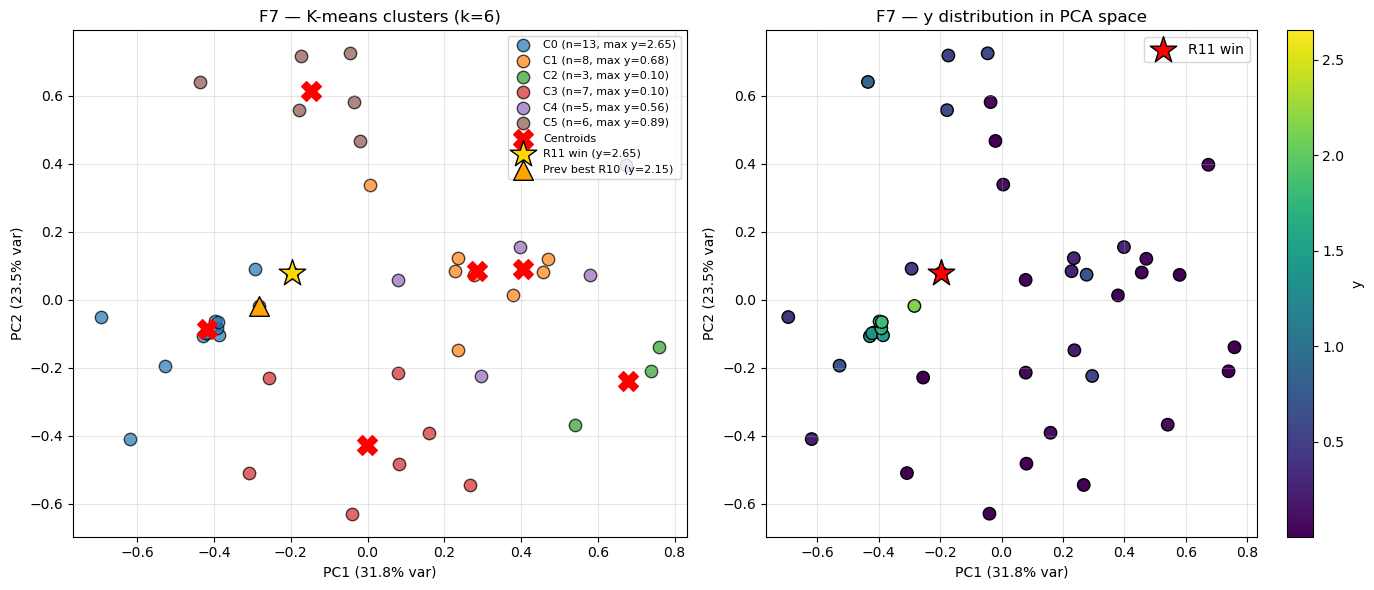

In [7]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
print(f"PCA explained variance: PC1 = {pca.explained_variance_ratio_[0]:.3f}, "
      f"PC2 = {pca.explained_variance_ratio_[1]:.3f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left: clusters
for i in range(best_k):
    members = labels == i
    ax1.scatter(X_pca[members, 0], X_pca[members, 1],
                s=80, edgecolor='black', alpha=0.7,
                label=f'C{i} (n={members.sum()}, max y={y[members].max():.2f})')
centroids_pca = pca.transform(km.cluster_centers_)
ax1.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            marker='X', s=200, color='red', label='Centroids', zorder=5)

# Highlight R11 win and previous best
R11_pca = pca.transform(R11_X.reshape(1, -1))[0]
R10_idx = np.argsort(y)[-2]  # second-best
R10_pca = pca.transform(X[R10_idx].reshape(1, -1))[0]
ax1.scatter(*R11_pca, marker='*', s=400, color='gold',
            edgecolor='black', label=f'R11 win (y={R11_y:.2f})', zorder=6)
ax1.scatter(*R10_pca, marker='^', s=200, color='orange',
            edgecolor='black', label=f'Prev best R10 (y={y[R10_idx]:.2f})', zorder=6)

ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
ax1.set_title(f'F7 — K-means clusters (k={best_k})')
ax1.legend(loc='best', fontsize=8); ax1.grid(alpha=0.3)

# Right: colored by y
sc = ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=y,
                  cmap='viridis', s=80, edgecolor='black')
plt.colorbar(sc, ax=ax2, label='y')
ax2.scatter(*R11_pca, marker='*', s=400, color='red',
            edgecolor='black', label='R11 win', zorder=5)
ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
ax2.set_title('F7 — y distribution in PCA space')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('F7_clusters_pca.png', dpi=100, bbox_inches='tight')
plt.show()

#### Step 6 — The new regime trajectory

F7's best-y trajectory across rounds illustrates how GP-EI bold move opened a new regime. We plot the running best-y vs round number.

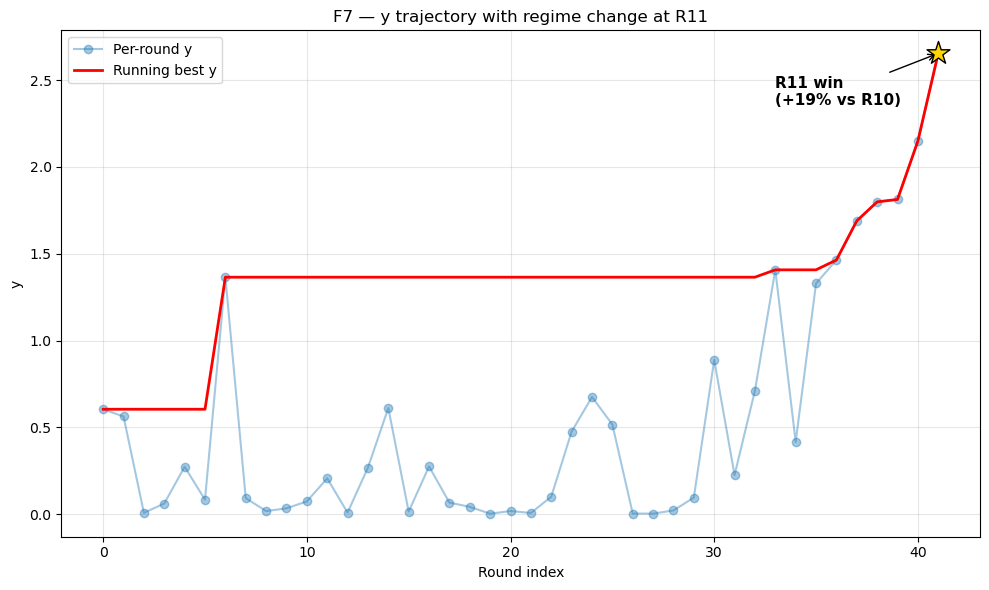

In [8]:
# Need round labels — if stored in data, use them
# Otherwise approximate from order (assuming X is in submission order)
if 'round_labels' in data.files:
    rounds = data['round_labels']
else:
    rounds = np.arange(len(X))

# Running best y
running_best = np.maximum.accumulate(y)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(rounds, y, 'o-', alpha=0.4, label='Per-round y', markersize=6)
ax.plot(rounds, running_best, 'r-', linewidth=2, label='Running best y')

# Annotate the R11 win
R11_round = R11_idx
ax.annotate(f'R11 win\n(+19% vs R10)',
            (R11_round, R11_y),
            xytext=(R11_round - 8, R11_y - 0.3),
            fontsize=11, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='black'))
ax.scatter(R11_round, R11_y, marker='*', s=300, color='gold',
           edgecolor='black', zorder=5)

ax.set_xlabel('Round index')
ax.set_ylabel('y')
ax.set_title('F7 — y trajectory with regime change at R11')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('F7_trajectory.png', dpi=100, bbox_inches='tight')
plt.show()

###### Step 7 — Strategic implications

##### What clustering tells us about F7

1. **F7 has a major regime change at R11** — GP-EI's bold multi-dim 
   move found a new high-y region geographically separated from the 
   old R7-R10 cluster.
2. **The R11 win is likely an outlier or single-point cluster** in 
   K-means — clustering algorithms can't anticipate regime changes 
   from a single new data point.
3. **Standard K-means metrics lag behind optimization progress** — by 
   the time the new region accumulates multiple points (which won't 
   happen in this budget), the clustering would update; until then, 
   the R11 win sits as an outlier.
4. **GP length scales correctly identify active dims (x1, x2, x4, x5, 
   x6) and irrelevant dim (x3)** — consistent with K-means' high-y 
   subset analysis.


##### Reflection material

**Past patterns**: F7 is a good example of trust well-calibrated bold GP-EI.GP calibration is now 0.05%, and GP-EI again proposes a multi-dim move.

**Clusters identified?**: F7 has at least two distinct high-y 
regions, K-means cannot anticipate the regime; only the optimizer can.

**Model's effectiveness**: Conservative single-dim probes yielded incremental gains. The bold GP-EI move in yielded 10× more in one round. Lesson: when calibration is excellent, boldness pays off — provided the move stays within or extends a single mode rather than crossing a valley.

**Clustering parallel**: F7 demonstrates the inverse of F2's case. In F2, the GP-EI extrapolated into an inter-cluster valley and failed. In F7, the GP-EI extrapolated into an unsampled but contiguous region and succeeded. The difference: F2's regions were true separate modes; F7's region is an extension of the same mode in a different sub-region. Visualizing this distinction in PCA space is critical.

**Plotted trends**: F7's y-vs-round shows the dramatic jump. 
The PCA scatter shows the new best point's geographic isolation from the 
older cluster.

**The within-cluster y std can mean different things on different functions — gradient direction (F7) vs noise/volatility (F6). Standard K-means doesn't distinguish these, but our interpretation must.**